In [15]:
# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Modern models
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier


# Supporting models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Imbalance handling
from imblearn.over_sampling import SMOTE

In [16]:
# =========================
# DATA UNDERSTANDING
# =========================

df = pd.read_csv("../dataset/predictive_maintenance.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [17]:
# =========================
# CEK MISSING VALUE
# =========================
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [18]:
# =========================
# DATA PREPROCESSING
# =========================

df = df.drop(columns=['UDI', 'Product ID', 'Target'])

# Encoding
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
df['Failure Type'] = le.fit_transform(df['Failure Type'])

# Split fitur dan target
X = df.drop(columns=['Failure Type'])
y = df['Failure Type']

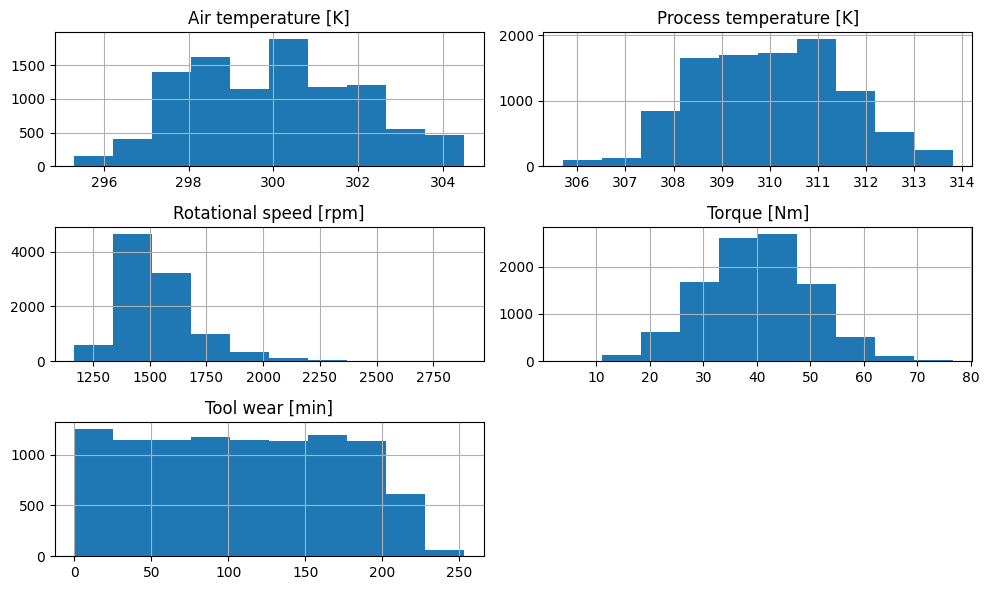

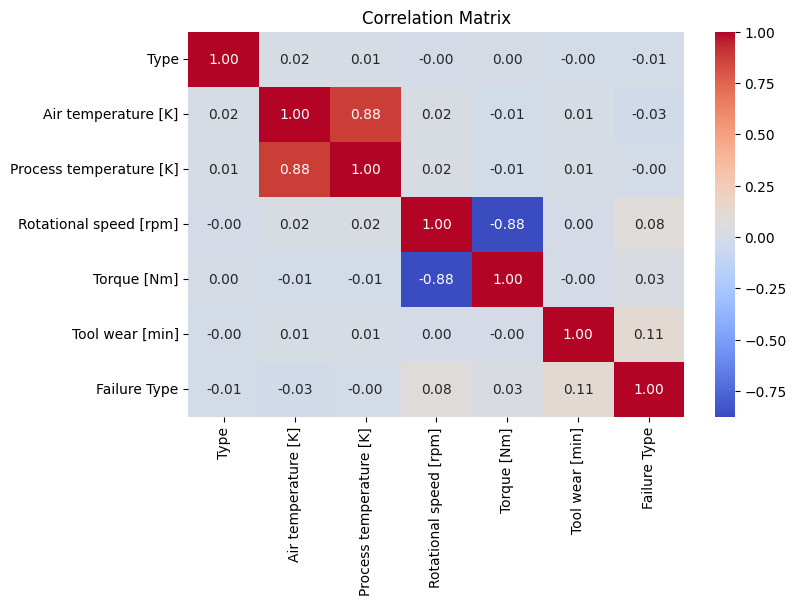

In [19]:
# =========================
# EDA
# =========================

features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Distribusi
df[features].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

# Korelasi
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

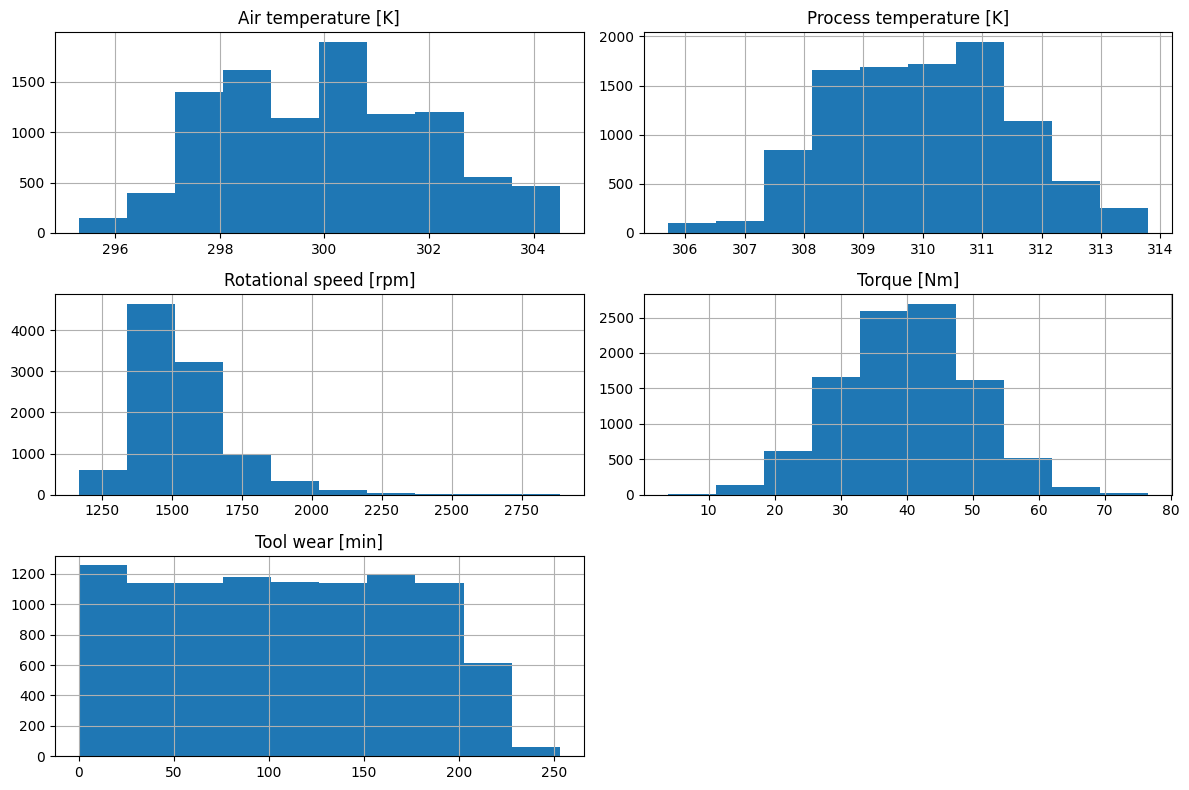

In [20]:
# =========================
# DISTRIBUSI DATA
# =========================

df[features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

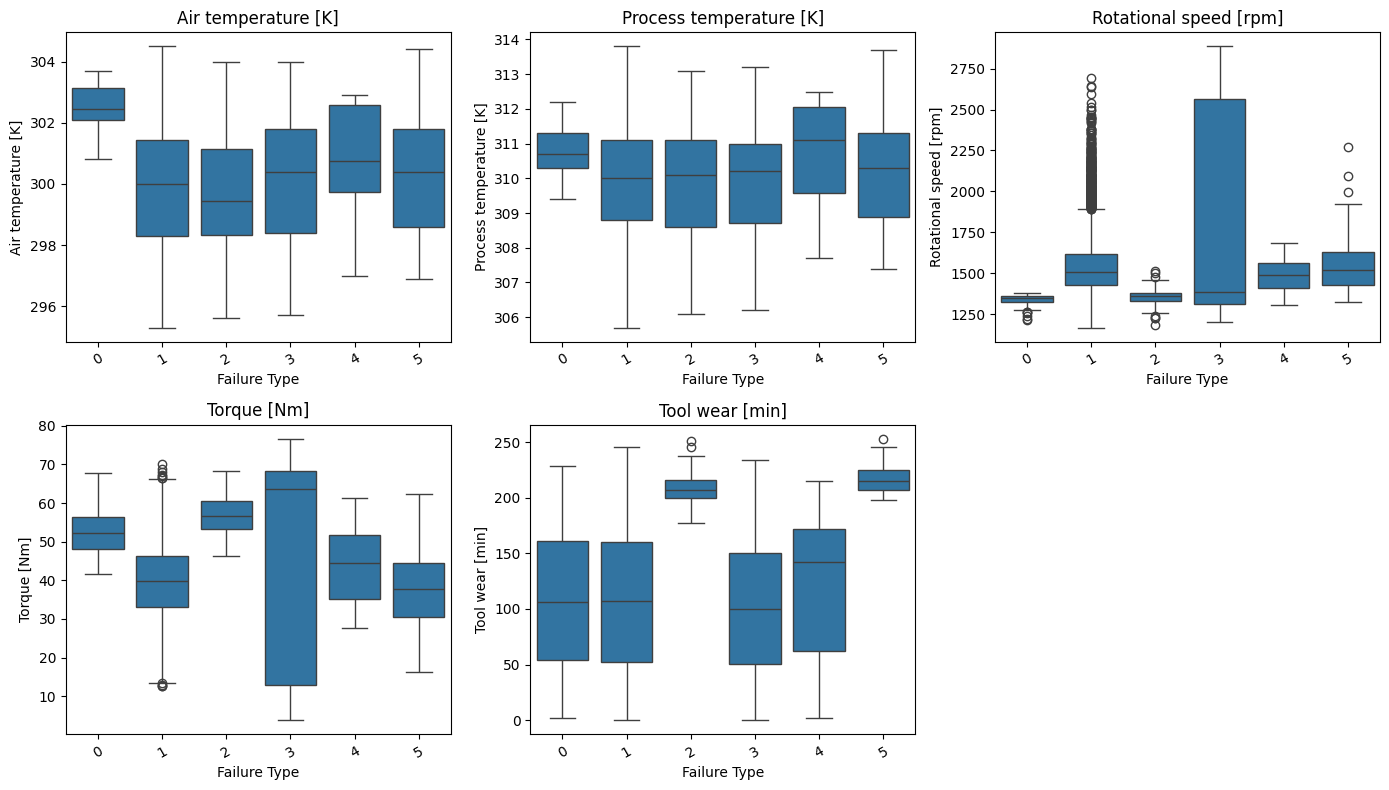

In [21]:
# =========================
# RELASI FITUR VS TARGET
# =========================

plt.figure(figsize=(14, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Failure Type', y=col, data=df)
    plt.xticks(rotation=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [22]:
# =========================
# DATA SPLITTING
# =========================

X = df.drop(columns=['Failure Type'])
y = df['Failure Type']

# Wajib pasang stratify=y
splits = {
    "70_30": train_test_split(X, y, test_size=0.3, random_state=42, stratify=y),
    "80_20": train_test_split(X, y, test_size=0.2, random_state=42, stratify=y),
    "90_10": train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
}

# =========================
# SCALING
# =========================
# Saran tambahan: Ganti StandardScaler jadi RobustScaler 
# Biar outlier (tanda kerusakan mesin) tetap aman!
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

models = {
    "XGBoost": (
        XGBClassifier(eval_metric='mlogloss'),
        {
            "n_estimators": [100,200],
            "max_depth": [3,5,7],
            "learning_rate": [0.01,0.1]
        }
    ),
    
    "HistGB": (
        HistGradientBoostingClassifier(),
        {
            "max_iter": [100,200],
            "max_depth": [None,10],
            "learning_rate": [0.01,0.1]
        }
    ),
    
    "Extra Trees": (
        ExtraTreesClassifier(),
        {
            "n_estimators": [100,200],
            "max_depth": [None,10,20]
        }
    ),
    
    "Random Forest": (
        RandomForestClassifier(),
        {
            "n_estimators": [100,200],
            "max_depth": [5,10,None]
        }
    ),
}

In [24]:
# =========================
# TRAINING MODEL
# =========================

trained_models = []
results = []

for split_name, (X_train, X_test, y_train, y_test) in splits.items():
    
    # Scaling
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

    for name, (model, params) in models.items():
        # RandomizedSearchCV untuk tuning hyperparameter
        rs = RandomizedSearchCV(
            model,
            params,
            n_iter=3,
            cv=3,
            random_state=42,
            n_jobs=-1
        )
        
        rs.fit(X_train_res, y_train_res)
        best_model = rs.best_estimator_
        
        # simpan semua untuk evaluasi nanti
        trained_models.append({
            "Split": split_name,
            "Model": name,
            "Model_obj": best_model,
            "X_test": X_test_scaled,
            "y_test": y_test
        })

C:\Users\Hi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [01:27:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Hi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [01:27:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Hi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [01:28:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [25]:
# =========================
# EVALUASI MODEL
# =========================

for item in trained_models:
    
    model = item["Model_obj"]
    y_test = item["y_test"]
    X_test = item["X_test"]
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results.append({
        "Split": item["Split"],
        "Model": item["Model"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })
    
    print(f"\n=== {item['Model']} | Split {item['Split']} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")


=== XGBoost | Split 70_30 ===
Accuracy  : 0.9173
Precision : 0.5288
Recall    : 0.6851
F1-score  : 0.5793

=== HistGB | Split 70_30 ===
Accuracy  : 0.9663
Precision : 0.5765
Recall    : 0.6342
F1-score  : 0.5990

=== Extra Trees | Split 70_30 ===
Accuracy  : 0.9633
Precision : 0.4920
Recall    : 0.5179
F1-score  : 0.5032

=== Random Forest | Split 70_30 ===
Accuracy  : 0.9450
Precision : 0.4657
Recall    : 0.6542
F1-score  : 0.5321

=== XGBoost | Split 80_20 ===
Accuracy  : 0.9240
Precision : 0.5690
Recall    : 0.6373
F1-score  : 0.5978

=== HistGB | Split 80_20 ===
Accuracy  : 0.9740
Precision : 0.5931
Recall    : 0.6384
F1-score  : 0.6130

=== Extra Trees | Split 80_20 ===
Accuracy  : 0.9700
Precision : 0.5412
Recall    : 0.5374
F1-score  : 0.5380

=== Random Forest | Split 80_20 ===
Accuracy  : 0.9470
Precision : 0.4853
Recall    : 0.6206
F1-score  : 0.5392

=== XGBoost | Split 90_10 ===
Accuracy  : 0.9310
Precision : 0.5682
Recall    : 0.6393
F1-score  : 0.5969

=== HistGB | Split

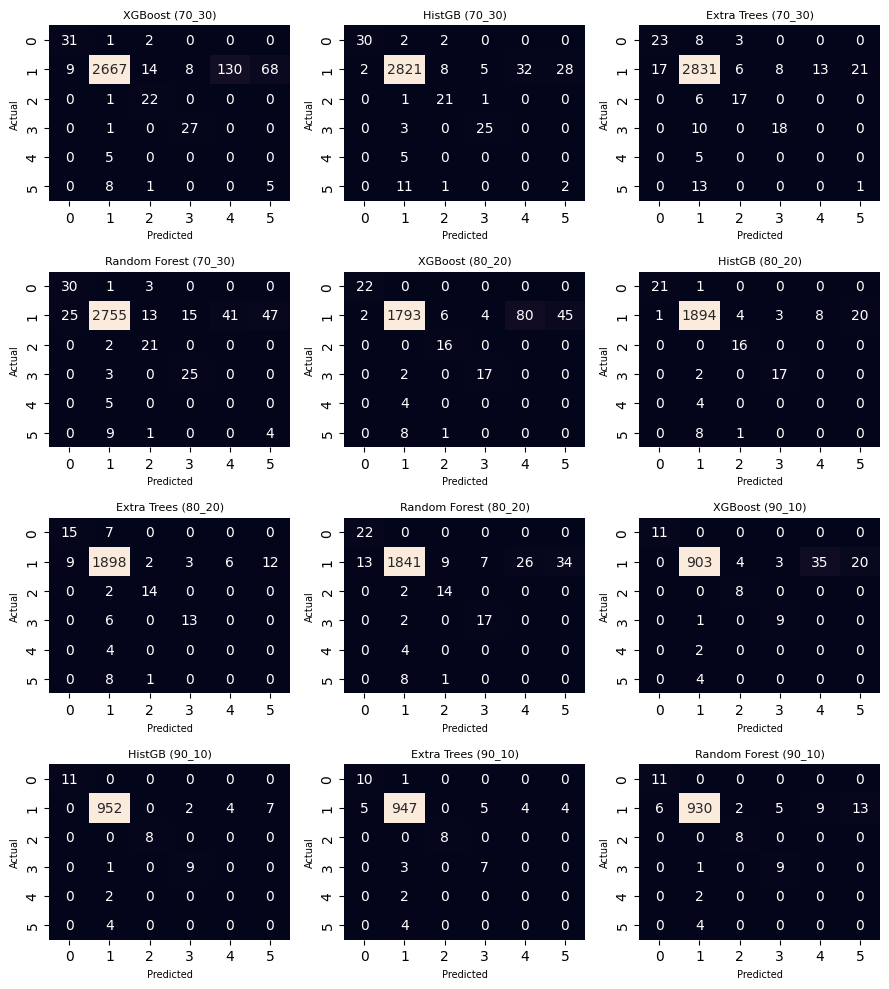

In [26]:
import math

n = len(trained_models)
cols = 3  # jumlah kolom (atur sendiri)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
axes = axes.flatten()

for i, item in enumerate(trained_models):
    
    model = item["Model_obj"]
    y_test = item["y_test"]
    X_test = item["X_test"]
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[i])
    
    axes[i].set_title(f"{item['Model']} ({item['Split']})", fontsize=8)
    axes[i].set_xlabel("Predicted", fontsize=7)
    axes[i].set_ylabel("Actual", fontsize=7)

# hapus subplot kosong kalau ada
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [27]:
# =========================
# PERBANDINGAN MODEL
# =========================

results_df = pd.DataFrame(results)
results_df

,Split,Model,Accuracy,Precision,Recall,F1-score
0,70_30,XGBoost,0.917333,0.528843,0.685107,0.579281
1,70_30,HistGB,0.966333,0.576522,0.634202,0.599032
2,70_30,Extra Trees,0.963333,0.491998,0.517907,0.503196
3,70_30,Random Forest,0.945000,0.465718,0.654213,0.532110
4,80_20,XGBoost,0.924000,0.569016,0.637292,0.597771
5,80_20,HistGB,0.974000,0.593099,0.638438,0.612987
6,80_20,Extra Trees,0.970000,0.541167,0.537408,0.538035
7,80_20,Random Forest,0.947000,0.485270,0.620604,0.539150
8,90_10,XGBoost,0.931000,0.568162,0.639292,0.596897
9,90_10,HistGB,0.980000,0.635147,0.647755,0.641125


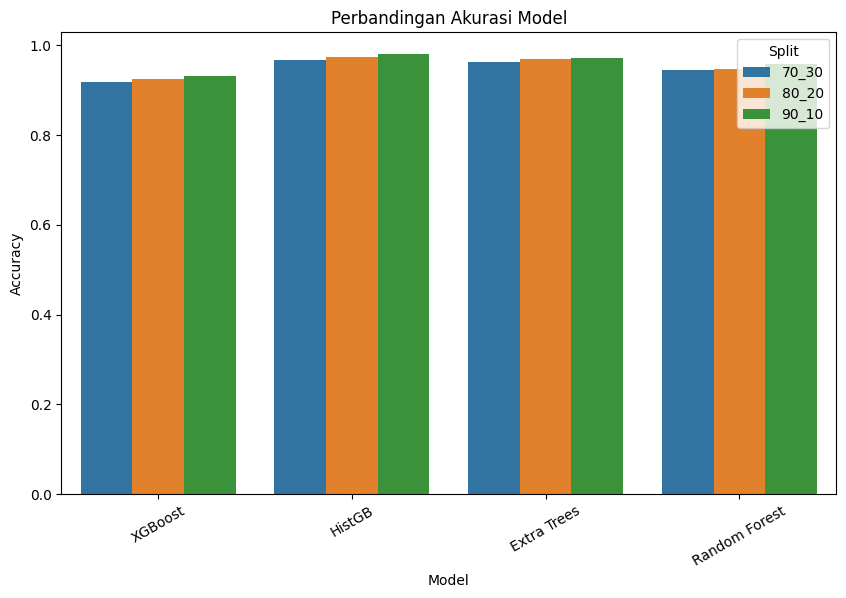

In [28]:
# =========================
# VISUALISASI
# =========================

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", hue="Split", data=results_df)
plt.xticks(rotation=30)
plt.title("Perbandingan Akurasi Model")
plt.show()